# Multi-asset forecasting with an LSTM

This notebook contains code for training and forecasting 22 stocks from the OMXS30 index
with an LSTM model.

Import data and create the dataloader

In [1]:
import pandas as pd
from data.MultiAssetDataset_v2 import MultiAssetSequencedDataset
from torch.utils.data import DataLoader

df = pd.read_csv("data/OMXS22_model_features_raw.csv", index_col = "Date", parse_dates = True)

tickers = df["Ticker"].unique().tolist()
#tickers = ["KINV-B.ST"] #, "SAND.ST"]
features = ["Close" ] #, "Return" ,"Volume","SMA20","EMA20","RSI14"]
target_col = "Close"
window   = 100
window_step_length = 6
horizon  = 5


train_stop = pd.Timestamp("2018-01-01")
val_stop   = pd.Timestamp("2023-12-31")

df_train = df[df.index < train_stop].copy()

df_val   = df[(df.index >= train_stop) & (df.index < val_stop)].copy()
df_test  = df[df.index >= val_stop].copy()


ds_train = MultiAssetSequencedDataset(df_train, tickers, features, target_col, False, window, window_step_length, horizon)
ds_val   = MultiAssetSequencedDataset(df_val,   tickers, features, target_col, False, window, window_step_length, horizon)
ds_test  = MultiAssetSequencedDataset(df_test,  tickers, features, target_col, False, window, window_step_length, horizon)

train_loader = DataLoader(ds_train, batch_size=32)
val_loader   = DataLoader(ds_val,   batch_size=32)
test_loader  = DataLoader(ds_test,  batch_size=32)

print(f"Train set input shape: {ds_train[0][0].shape}")
print(f"Train set target shape: {ds_train[0][1].shape}")
print(f"Dataset length: {len(ds_train) + len(ds_val) + len(ds_test)}")


Train set input shape: torch.Size([100, 22])
Train set target shape: torch.Size([22])
Dataset length: 1020


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from multi_asset_models.MultiAssetLSTM import MultiAssetLSTM
from train.Trainer import Trainer

model = MultiAssetLSTM(
    n_assets=len(tickers),
    n_features=len(features),
    hidden_size=128,
    num_layers=3,
    dropout=0.2,
    horizon=horizon
)

criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


num_epochs   = 200
patience     = num_epochs
save_path    = "best_multiasset_lstm.pt"

trainer = Trainer(model, optimizer, criterion)
history = trainer.fit(
    train_loader = train_loader,
    val_loader   = val_loader,
    epochs       = num_epochs,
    patience     = patience,
    save_path    = save_path
)

model.load_state_dict(torch.load(save_path))
test_loss = trainer.eval_epoch(test_loader)
print(f"Test loss: {test_loss:.4f}")

Epoch 1/200 - train_loss: 0.6276, val_loss: 0.9594
Epoch 2/200 - train_loss: 0.8024, val_loss: 0.6676
Epoch 3/200 - train_loss: 0.5680, val_loss: 0.7865
Epoch 4/200 - train_loss: 0.5690, val_loss: 0.7509
Epoch 5/200 - train_loss: 0.4784, val_loss: 0.6729
Epoch 6/200 - train_loss: 0.3911, val_loss: 0.7253
Epoch 7/200 - train_loss: 0.4613, val_loss: 0.6376
Epoch 8/200 - train_loss: 0.3851, val_loss: 0.6814
Epoch 9/200 - train_loss: 0.4766, val_loss: 0.6707
Epoch 10/200 - train_loss: 0.4293, val_loss: 0.6922
Epoch 11/200 - train_loss: 0.5221, val_loss: 0.6932
Epoch 12/200 - train_loss: 0.4936, val_loss: 0.7808
Epoch 13/200 - train_loss: 0.3549, val_loss: 0.6404
Epoch 14/200 - train_loss: 0.3594, val_loss: 0.6248
Epoch 15/200 - train_loss: 0.3223, val_loss: 0.6106
Epoch 16/200 - train_loss: 0.3382, val_loss: 0.8308
Epoch 17/200 - train_loss: 0.4573, val_loss: 0.6073
Epoch 18/200 - train_loss: 0.3742, val_loss: 0.6168
Epoch 19/200 - train_loss: 0.4720, val_loss: 0.7360
Epoch 20/200 - train_

Naive MAE: 0.9024


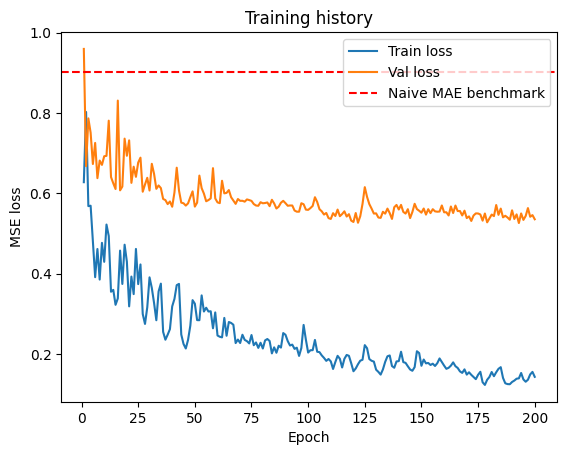

In [3]:
import numpy as np
import matplotlib.pyplot as plt

ys = []
for _, y in DataLoader(ds_test, batch_size=128):
    ys.append(y)
ys = torch.cat(ys, dim=0).numpy()
if ys.ndim == 3:
    ys = ys[:, :, 0]

naive_errors = np.abs(ys[horizon:] - ys[:-horizon])
naive_mae = naive_errors.mean()
print(f"Naive MAE: {naive_mae:.4f}")

epochs = np.arange(1, len(history['train_loss']) + 1)
plt.figure()
plt.plot(epochs, history['train_loss'], label='Train loss')
if 'val_loss' in history:
    plt.plot(epochs, history['val_loss'], label='Val loss')
plt.axhline(y=naive_mae, color='r', linestyle='--', label='Naive MAE benchmark')
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.title('Training history')
plt.legend()
plt.show()

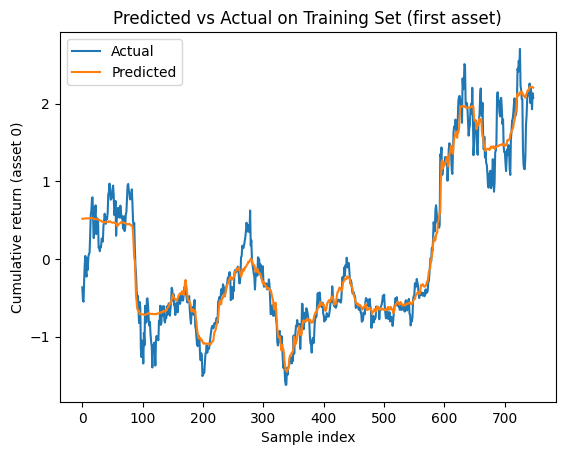

In [9]:
# Load best model
model.load_state_dict(torch.load(save_path))
model.eval()
all_preds = []
all_trues = []

with torch.no_grad():
    for Xb, yb in train_loader:
        preds = model(Xb)  # (B, A, H)
        # välj asset 0 och horizon 0 för plottning
        all_preds.append(preds[:, 3].cpu().numpy())
        all_trues.append(yb[:, 3].cpu().numpy())

# Konkatenera

all_preds = np.concatenate(all_preds)
all_trues = np.concatenate(all_trues)

all_preds = all_preds #* scaler_stds[target_col] + scaler_means[target_col]
all_trues = all_trues #* scaler_stds[target_col] + scaler_means[target_col]

# Naive benchmark guessing next value = current value

n_plot = 10000
plt.figure()
plt.plot(all_trues[:n_plot], label='Actual')
plt.plot(all_preds[:n_plot], label='Predicted')
plt.xlabel('Sample index')
plt.ylabel('Cumulative return (asset 0)')
plt.title('Predicted vs Actual on Training Set (first asset)')
plt.legend()
plt.show()

In [106]:
import deeplay as dl


gru_dl = dl.RecurrentModel(
    in_features=len(features)*len(tickers),
    hidden_features=[128, 128, 128],
    out_features=len(tickers),
    rnn_type="GRU",
    dropout=0.2,
)
gru_stacked = dl.Regressor(gru_dl, optimizer=dl.Adam(lr=0.001)).create()

trainer = dl.Trainer(max_epochs=50, accelerator="auto")
trainer.fit(gru_stacked, train_loader, val_loader)

train_losses = trainer.history.history["train_loss_epoch"]["value"]
val_losses = trainer.history.history["val_loss_epoch"]["value"][1:]


  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | train
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollection | 0      | train
3 | test_metrics  | MetricCollection | 0      | train
4 | model         | RecurrentModel   | 248 K  | train
5 | optimizer     | Adam             | 0      | train
-----------------------------------------------------------
248 K     Trainable params
0         Non-trainable params
248 K     Total params
0.994     Total estimated model params size (MB)
24        Modules in train mode
0         Modules in eval mode


C:\Users\peogr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
C:\Users\peogr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
C:\Users\peogr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training

Epoch 49: 100%|██████████| 24/24 [00:04<00:00,  5.99it/s, v_num=21, train_loss_step=0.332, val_loss_step=0.400, val_loss_epoch=0.191, train_loss_epoch=0.163]  


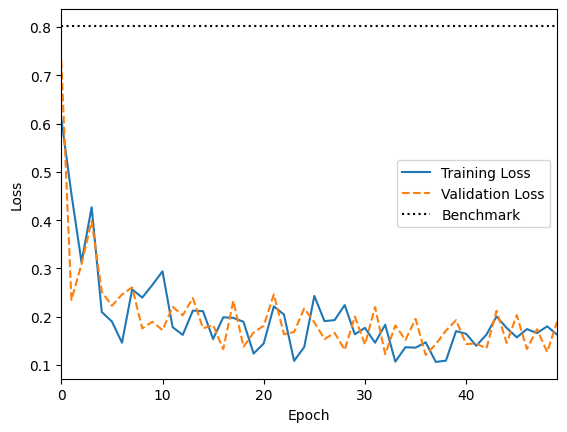

In [107]:
def plot_training(epochs, train_losses, val_losses, benchmark):
    """Plot the training and validation losses."""
    plt.plot(range(epochs), train_losses, label="Training Loss")
    plt.plot(range(epochs), val_losses, "--", label="Validation Loss")
    plt.plot([0, epochs - 1], [benchmark, benchmark], ":k", label="Benchmark")
    plt.xlabel("Epoch")
    plt.xlim([0, epochs - 1])
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_training(50, train_losses, val_losses, benchmark = naive_mae)

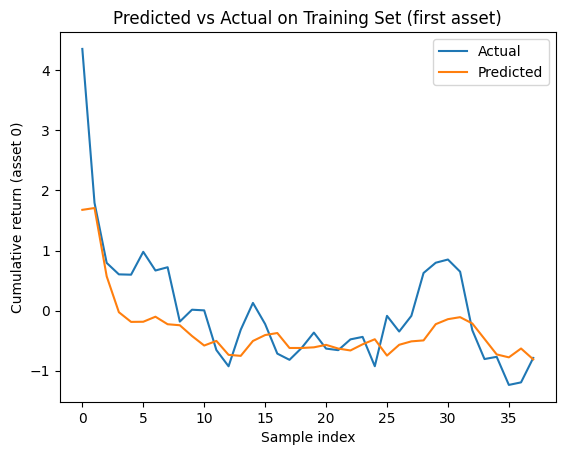

In [109]:
# Plot predictions vs actual on test set
import torch
import numpy as np
import matplotlib.pyplot as plt
all_preds = []
all_trues = []

with torch.no_grad():
    for Xb, yb in test_loader:
        preds = gru_stacked(Xb)  # (B, A, H)
        # välj asset 0 och horizon 0 för plottning
        all_preds.append(preds[:, 0].cpu().numpy())
        all_trues.append(yb[:, 0].cpu().numpy())
# Konkatenera
all_preds = np.concatenate(all_preds)
all_trues = np.concatenate(all_trues)
all_preds = all_preds #* scaler_stds[target_col] + scaler_means[target_col]
all_trues = all_trues #* scaler_stds[target_col] + scaler_means[target_col]
n_plot = 200
plt.figure()
plt.plot(all_trues[:n_plot], label='Actual')
plt.plot(all_preds[:n_plot], label='Predicted')
plt.xlabel('Sample index')
plt.ylabel('Cumulative return (asset 0)')
plt.title('Predicted vs Actual on Training Set (first asset)')
plt.legend()
plt.show()


In [110]:
class CrossAttentionGRUV2(nn.Module):
    def __init__(self, in_dim, hidden_dim, num_hidden_layers, out_dim, dropout, num_heads):
        super().__init__()
        self.gru_model = nn.GRU(in_dim, hidden_dim, num_layers=num_hidden_layers, dropout=dropout, batch_first=True)
        self.input_proj = nn.Linear(in_dim, hidden_dim)
        self.cross_attn = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=num_heads, kdim=in_dim, vdim=in_dim, dropout=0, batch_first=True)
        self.fuse_fc = nn.Sequential(
            nn.Linear(hidden_dim*2, hidden_dim),
            nn.ReLU()
        )
        self.fc = nn.Linear(hidden_dim, out_dim)
        self._stored_attn_weights = None

    def get_attn_weights(self):
        return self._stored_attn_weights

    def forward(self, x):
        gru_out, _ = self.gru_model(x)

        x_proj = x #self.input_proj(x)

        cross_attn_out, cross_attn_weights = self.cross_attn(query=gru_out, key=x_proj, value=x_proj)

        self._stored_attn_weights = cross_attn_weights.detach()
        #print('gru:', gru_out)
        #print('cross attn: ', cross_attn_out)

        combined = torch.cat([gru_out, cross_attn_out], dim=-1)
        fused = self.fuse_fc(combined)
        #print(combined.shape)

        final_step = fused[:, -1, :]
        #print(final_step.shape)

        output = self.fc(final_step)

        return output

In [ ]:
cross_attention_gru_model = CrossAttentionGRUV2(in_dim=len(tickers)*len(features), hidden_dim=144, num_hidden_layers=3, out_dim=len(tickers), dropout=0.1, num_heads=24)

cross_attention_gru_reg = dl.Regressor(cross_attention_gru_model, optimizer=dl.Adam(lr=0.001)).create()

trainer_cross_gru = dl.Trainer(max_epochs=50, accelerator="auto")
trainer_cross_gru.fit(cross_attention_gru_reg, train_loader, val_loader)

train_losses = trainer_cross_gru.history.history["train_loss_epoch"]["value"]
val_losses = trainer_cross_gru.history.history["val_loss_epoch"]["value"][1:]


  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | train
1 | train_metrics | MetricCollection    | 0      | train
2 | val_metrics   | MetricCollection    | 0      | train
3 | test_metrics  | MetricCollection    | 0      | train
4 | model         | CrossAttentionGRUV2 | 398 K  | train
5 | optimizer     | Adam                | 0      | train
--------------------------------------------------------------
398 K     Trainable params
0         Non-trainable params
398 K     Total params
1.594     Total estimated model params size (MB)
14        Modules in train mode
0         Modules in eval mode


Epoch 49: 100%|██████████| 24/24 [00:06<00:00,  3.95it/s, v_num=23, train_loss_step=0.994, val_loss_step=0.290, val_loss_epoch=0.354, train_loss_epoch=0.322] 


TypeError: only integer scalar arrays can be converted to a scalar index

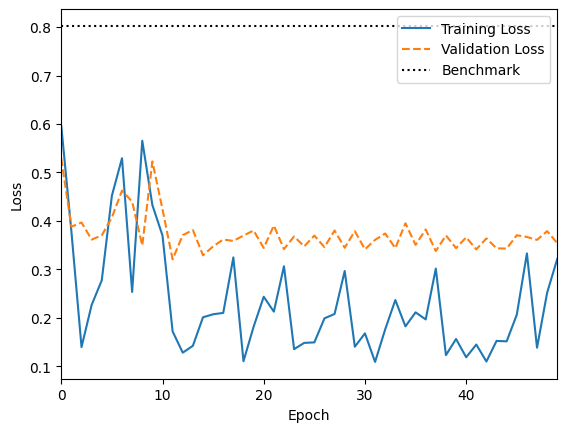

In [113]:
plot_training(50, train_losses, val_losses, naive_mae)